# Artificial Non-Streaming Demo

This notebook mirrors the lean ZINC non-streaming demo, but uses an artificial NetworkX dataset generated in memory.

- source: cycle -> connector path -> star-ray graphs
- sample count: `DATASET_SIZE`
- fit mode: materialize generated graphs, then train normally
- outputs: 7 samples without feasibility filtering, then 7 with filtering


In [37]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import sys
from IPython.core.display import HTML
from pathlib import Path
import random
import warnings
import numpy as np

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

warnings.filterwarnings('ignore', message=r".*`isinstance\(treespec, LeafSpec\)` is deprecated.*")

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'conditional_node_field_graph_generator').is_dir():
        repo_root = candidate.resolve()
        break
else:
    raise RuntimeError(
        'Could not locate the NodeField repository from the current working directory. '
        'Start Jupyter from the repo root or the notebooks directory.'
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator
from conditional_node_field_graph_generator.extensions.demo.artificial import generate_artificial_dataset


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch version: 2.13.0
CUDA available: False


In [38]:
RANDOM_SEED = 42
DATASET_SIZE =50000
N_ITERATIONS = 1
CYCLE_LENGTH = [3,8]
NUM_CYCLES = 1
PATH_LENGTH = 2
NUM_RAYS = 3
RAY_LENGTH = 1
NODE_ALPHABET_SIZE = 3
EDGE_ALPHABET_SIZE = 1
NODE_ALPHABET_KIND = 'int'
EDGE_ALPHABET_KIND = 'int'
COMPONENT_SPECIFIC_ALPHABETS = True

FIT_BATCH_SIZE = 128
MAXIMUM_EPOCHS = 350
LOSS_CURVES_PDF_EVERY_N_EPOCHS = 10
EMBEDDING_DIM = 128
CYCLE_COUNT_TOKEN = '' if NUM_CYCLES == 1 else f'-nc{NUM_CYCLES}'
ITERATION_COUNT_TOKEN = '' if N_ITERATIONS == 1 else f'-ni{N_ITERATIONS}'
MODEL_NAME = (
    f'artificial-cycle-path-star-n{DATASET_SIZE}'
    f'-c{CYCLE_LENGTH}{CYCLE_COUNT_TOKEN}{ITERATION_COUNT_TOKEN}-p{PATH_LENGTH}-r{NUM_RAYS}x{RAY_LENGTH}'
    f'-d{EMBEDDING_DIM}-b{FIT_BATCH_SIZE}-e{MAXIMUM_EPOCHS}'
)
DECODER_N_JOBS = -1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)




Saved artificial dataset config: artificial-cycle-path-star-n50000-c3-8-p2-r3x1-na3.yaml
Loaded 50000 artificial graphs into memory for non-streaming fit.
Node count min/median/max = 9/11/14
Edge count min/median/max = 9/11/14
Metadata: {'cycle_length': 8, 'num_cycles': 1, 'n_iterations': 1, 'path_length': 2, 'num_rays': 3, 'ray_length': 1, 'iteration_parameters': [{'cycle_length': 8, 'num_cycles': 1, 'path_length': 2, 'num_rays': 3, 'ray_length': 1}], 'node_alphabet_size': 3, 'edge_alphabet_size': 1, 'component_specific_alphabets': True, 'node_alphabets_by_component': {'cycle': [0, 1, 2], 'path': [3, 4, 5], 'star': [6, 7, 8]}, 'edge_alphabets_by_component': {'cycle': [0], 'path': [1], 'star': [2]}}


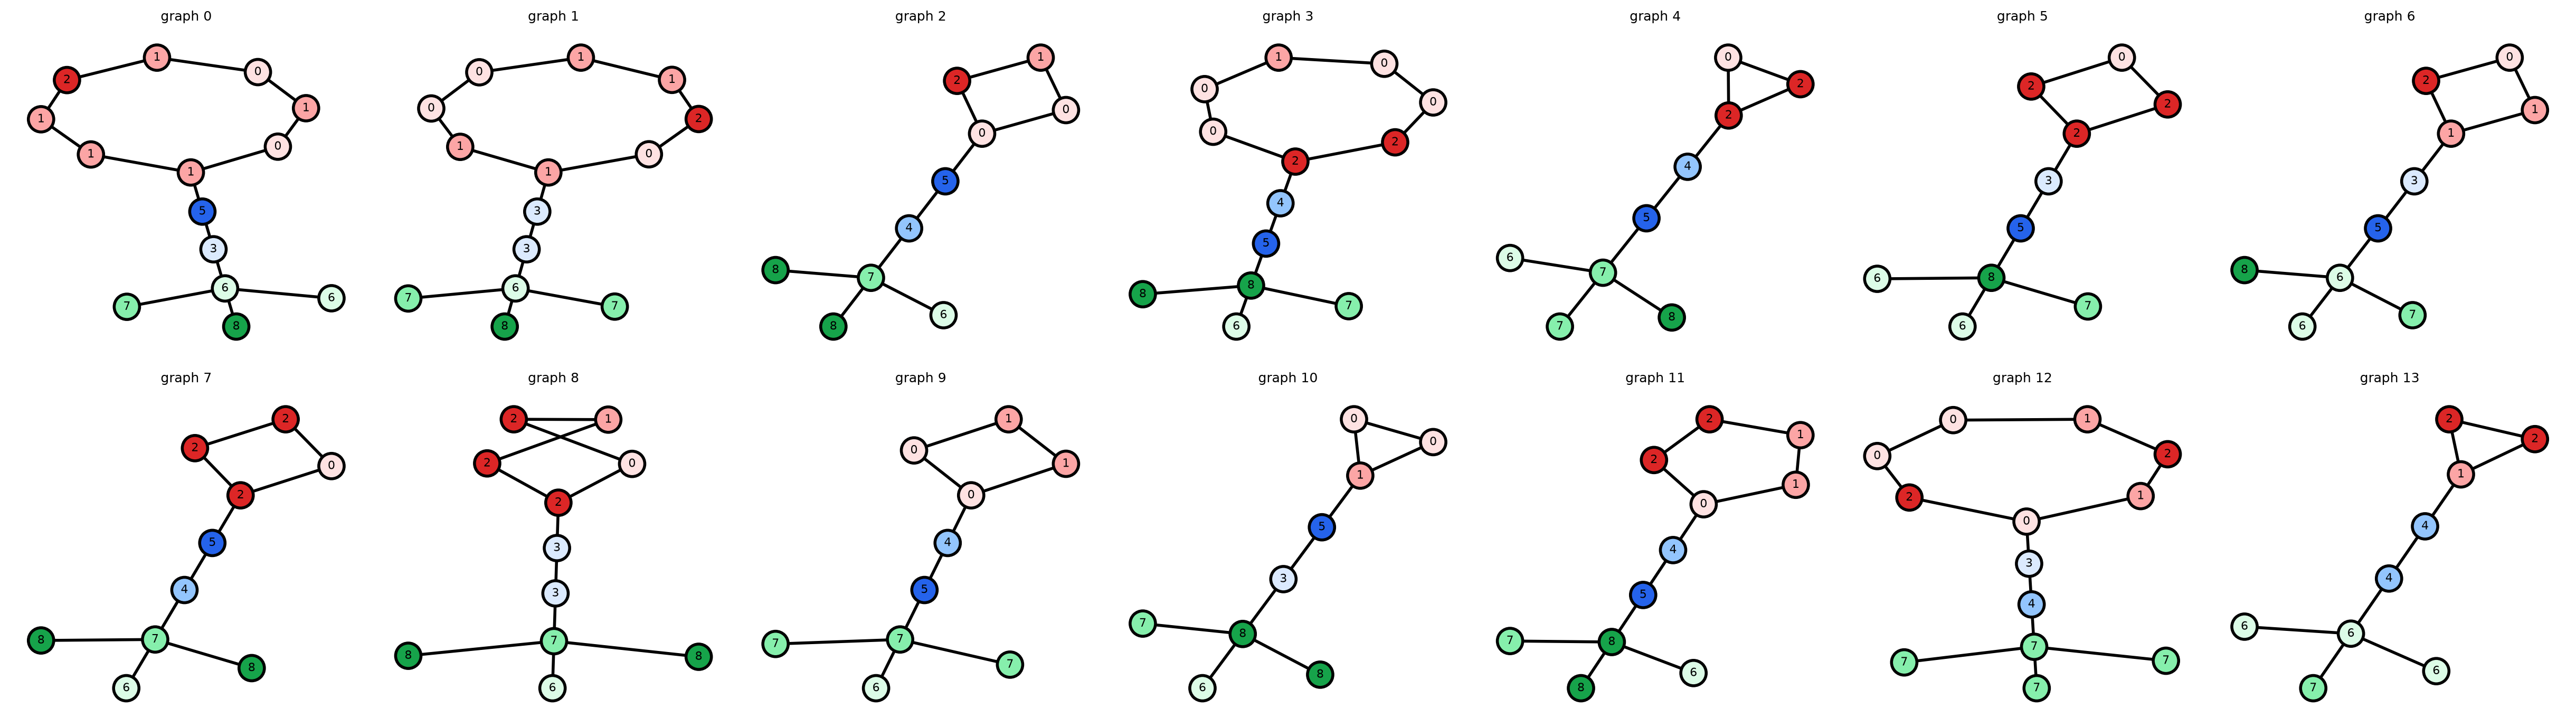

In [39]:
graphs, plot_artificial_graphs = generate_artificial_dataset(
    num_graphs=DATASET_SIZE,
    n_iterations=N_ITERATIONS,
    cycle_length=CYCLE_LENGTH,
    num_cycles=NUM_CYCLES,
    path_length=PATH_LENGTH,
    num_rays=NUM_RAYS,
    ray_length=RAY_LENGTH,
    node_alphabet_size=NODE_ALPHABET_SIZE,
    edge_alphabet_size=EDGE_ALPHABET_SIZE,
    node_alphabet_kind=NODE_ALPHABET_KIND,
    edge_alphabet_kind=EDGE_ALPHABET_KIND,
    component_specific_alphabets=COMPONENT_SPECIFIC_ALPHABETS,
    seed=RANDOM_SEED,
)

node_counts = np.array([graph.number_of_nodes() for graph in graphs])
edge_counts = np.array([graph.number_of_edges() for graph in graphs])
print(f'Loaded {len(graphs)} artificial graphs into memory for non-streaming fit.')
print(f'Node count min/median/max = {node_counts.min()}/{np.median(node_counts):.0f}/{node_counts.max()}')
print(f'Edge count min/median/max = {edge_counts.min()}/{np.median(edge_counts):.0f}/{edge_counts.max()}')
print('Metadata:', graphs[0].graph['metadata'])

num=7*2
_ = plot_artificial_graphs(
    graphs[:num],
    n_cols=7,
    titles=[f'graph {idx}' for idx in range(num)],
    size=3.5,
)



In [40]:

graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    node_embedding_svd_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=3,
    transformer_attention_head_count=4,
    locality_horizon=2,
    sparse_supervision_mask_ratio=0.5,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=1,
    decoder_n_jobs=DECODER_N_JOBS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
graph_generator.loss_curves_pdf_every_n_epochs = LOSS_CURVES_PDF_EVERY_N_EPOCHS
def render_artificial_graphs(decoded_graphs, **kwargs):
    graph_list = list(decoded_graphs)
    titles = kwargs.get('titles')
    plot_artificial_graphs(
        graph_list,
        n_cols=max(1, min(7, len(graph_list))),
        titles=titles,
    )


graph_generator.graph_decoder.diagnostic_graph_renderer = render_artificial_graphs

TRAINING_PROGRESS_PDF_PATH = ARTIFACT_ROOT / 'samples' / MODEL_NAME / 'training_samples.pdf'
print(f'Training sample PDF: {TRAINING_PROGRESS_PDF_PATH}')

Configured graph generator model_name=artificial-cycle-path-star-n50000-c-3-8-p2-r3x1-d128-b128-e350 model_dir=/Users/f.costa/Code/NodeField/.artifacts/saved_generators
Training sample PDF: /Users/f.costa/Code/NodeField/.artifacts/samples/artificial-cycle-path-star-n50000-c[3, 8]-p2-r3x1-d128-b128-e350/training_samples.pdf


Fit target model_name=artificial-cycle-path-star-n50000-c-3-8-p2-r3x1-d128-b128-e350 model_dir=/Users/f.costa/Code/NodeField/.artifacts/saved_generators
Fitting model on 50000 graphs
Fitting graph vectorizer on 50000 graphs
Finished fitting graph vectorizer on 50000 graphs in 0m 0.0s
Fitting node graph vectorizer on 50000 graphs
Finished fitting node graph vectorizer on 50000 graphs in 0m 0.0s
Encoding node embeddings for 50000 graphs
Finished encoding node embeddings for 50000 graphs in 0m 55.1s
Encoding graph embeddings for 50000 graphs
Finished encoding graph embeddings for 50000 graphs in 1m 0.0s
Fitting embedding SVDs
Stacking raw node embeddings for SVD.
Stacked node embedding matrix: shape=(574266, 2048), sparse=True, nnz=86904108, density=0.073892.
Prepared graph embedding matrix: shape=(50000, 2048), sparse=True, nnz=39027457, density=0.381128.
Sampled node embedding SVD fit rows: 574266 -> 10000.
Fitting node embedding SVD on shape=(10000, 2048), sparse=True, nnz=1511748, den

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Epoch 10/350 | ETA 4h 02m 34s:
  train total=   30.382 | node_field    23.505 [77.4%] |        deg   0.42688 [1.4%] |      exist   0.21071 [0.7%] | node_count   0.00472 [<0.1%]
  val   total=   28.755 | node_field    23.279 [81.0%] |        deg   0.32330 [1.1%] |      exist   0.20576 [0.7%] | node_count   0.00454 [<0.1%]
  train                 | node_label   0.66181 [2.2%] | edge_label   0.08416 [0.3%] |       edge   0.89611 [2.9%] | edge_count    4.2109 [13.9%] | deg_edge_consistency   0.00013 [<0.1%]
  val                   | node_label   0.48005 [1.7%] | edge_label   0.05241 [0.2%] |       edge   0.75434 [2.6%] | edge_count    3.3365 [11.6%] | deg_edge_consistency   0.00010 [<0.1%]
  train                 |        aux   0.38131 [1.3%] | dominant=node_field [77.4%]
  val                   |        aux   0.31978 [1.1%] | dominant=node_field [81.0%]
Epoch 20/350 | ETA 3h 22m 11s:
  train total=   27.814 | node_field    23.170 [83.3%] |        deg   0.24554 [0.9%] |      exist   0.1619

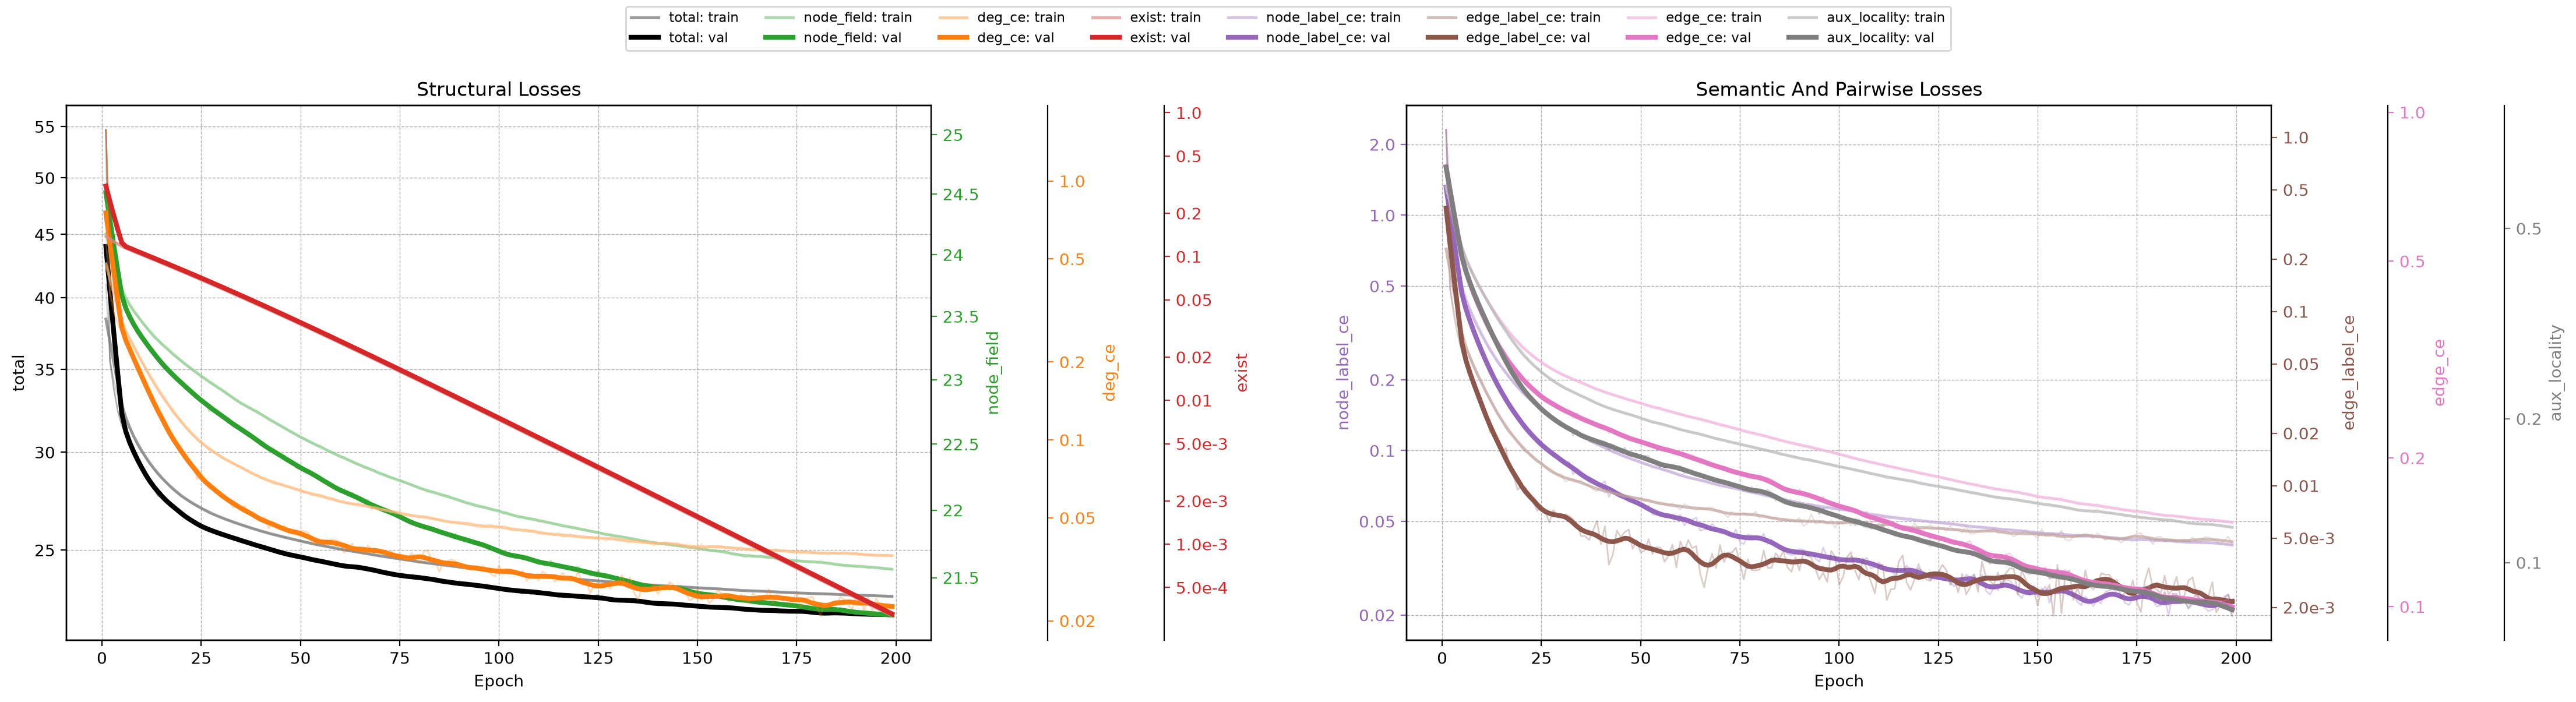

training_graph_conditioning_ = 50000
is_fitted_ = True
CPU times: user 1h 7min 3s, sys: 23min 20s, total: 1h 30min 23s
Wall time: 1h 57min 49s


In [41]:
%%time
graph_generator.fit(
    graphs,
    sample_training_progress=False,
    sample_training_progress_n_samples=1,
    sample_training_progress_every_n_epochs=30,
    sample_training_progress_pdf_path=TRAINING_PROGRESS_PDF_PATH,
    sample_training_progress_plot_fn=plot_artificial_graphs,
)
print('training_graph_conditioning_ =', len(graph_generator.training_graph_conditioning_))
print('is_fitted_ =', graph_generator.is_fitted_)


In [42]:
# Optional reload path for a previously saved artificial non-streaming model.
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)

list_saved_graph_generators(SAVED_GENERATOR_ROOT)
MODEL_FILENAME = f'{MODEL_NAME}.pkl'
graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)


,name,modified,size_mb
0,zinc-d80-n108642-size10-22.pkl,2026-07-17 01:13,226.300000
1,artificial-cycle-path-star-n50000-c-3-8-p2-r3x1-d128-b128-e350.pkl,2026-07-17 01:06,61.000000
2,zinc-d80-n10000-size10-18.pkl,2026-07-16 16:23,32.100000
3,zinc-d80-n2250-size10-18.pkl,2026-07-16 15:39,16.900000
4,zinc-d80-n225-size10-18.pkl,2026-07-16 15:20,12.300000
5,artificial-cycle-path-star-n10000-c-3-8-p2-r3x1-d128-b128-e350.pkl,2026-07-16 15:12,21.300000
6,artificial-cycle-path-star-n1000-c-3-8-p2-r3x1-d128-b128-e350.pkl,2026-07-16 14:46,12.400000
7,artificial-cycle-path-star-n100-c-3-8-p2-r3x1-d128-b128-e350.pkl,2026-07-16 13:33,11.000000


Loaded graph generator: artificial-cycle-path-star-n50000-c-3-8-p2-r3x1-d128-b128-e350.pkl
/Users/f.costa/Code/NodeField/.artifacts/saved_generators/artificial-cycle-path-star-n50000-c-3-8-p2-r3x1-d128-b128-e350.pkl


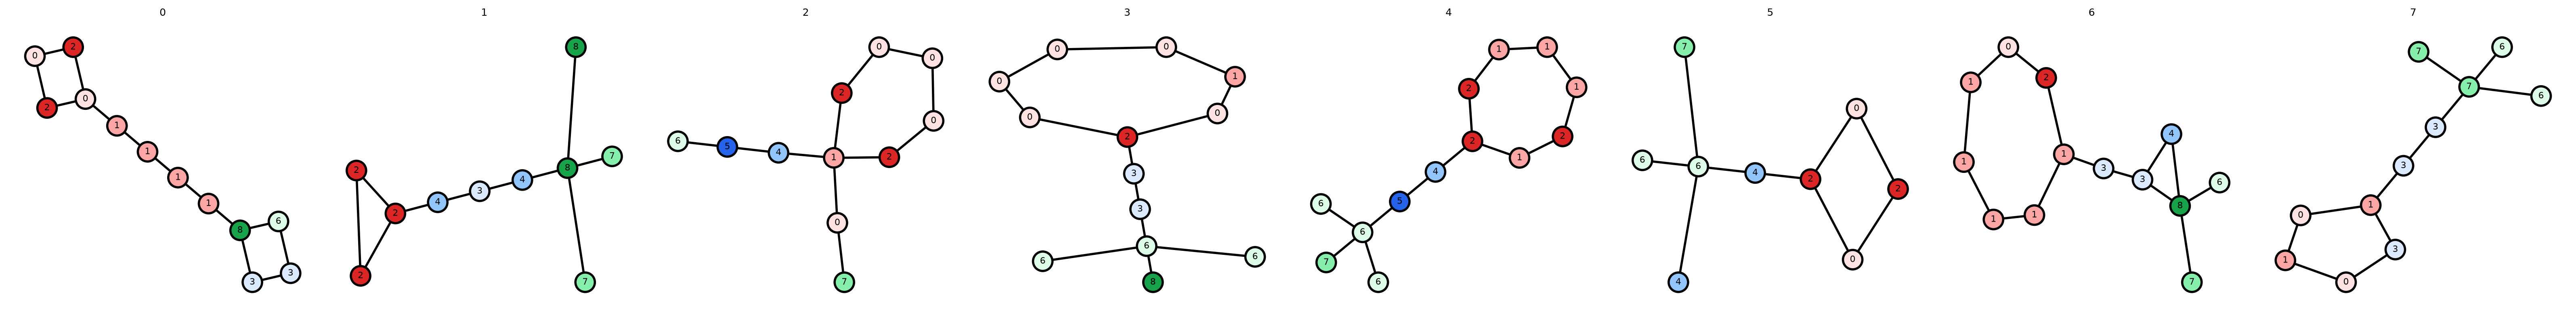

In [43]:
N_SAMPLES = 8
FEASIBILITY_EFFORT = 2
FEASIBILITY_FILTER = 'none' # 'none', 'fallback', or 'strict'
filtered_samples = graph_generator.sample(
    n_samples=N_SAMPLES,
    feasibility_effort=FEASIBILITY_EFFORT,
    feasibility_filter=FEASIBILITY_FILTER,
)
_ = plot_artificial_graphs(
    filtered_samples,
    n_cols=N_SAMPLES,
    titles=[f'{idx}' for idx in range(len(filtered_samples))],
)

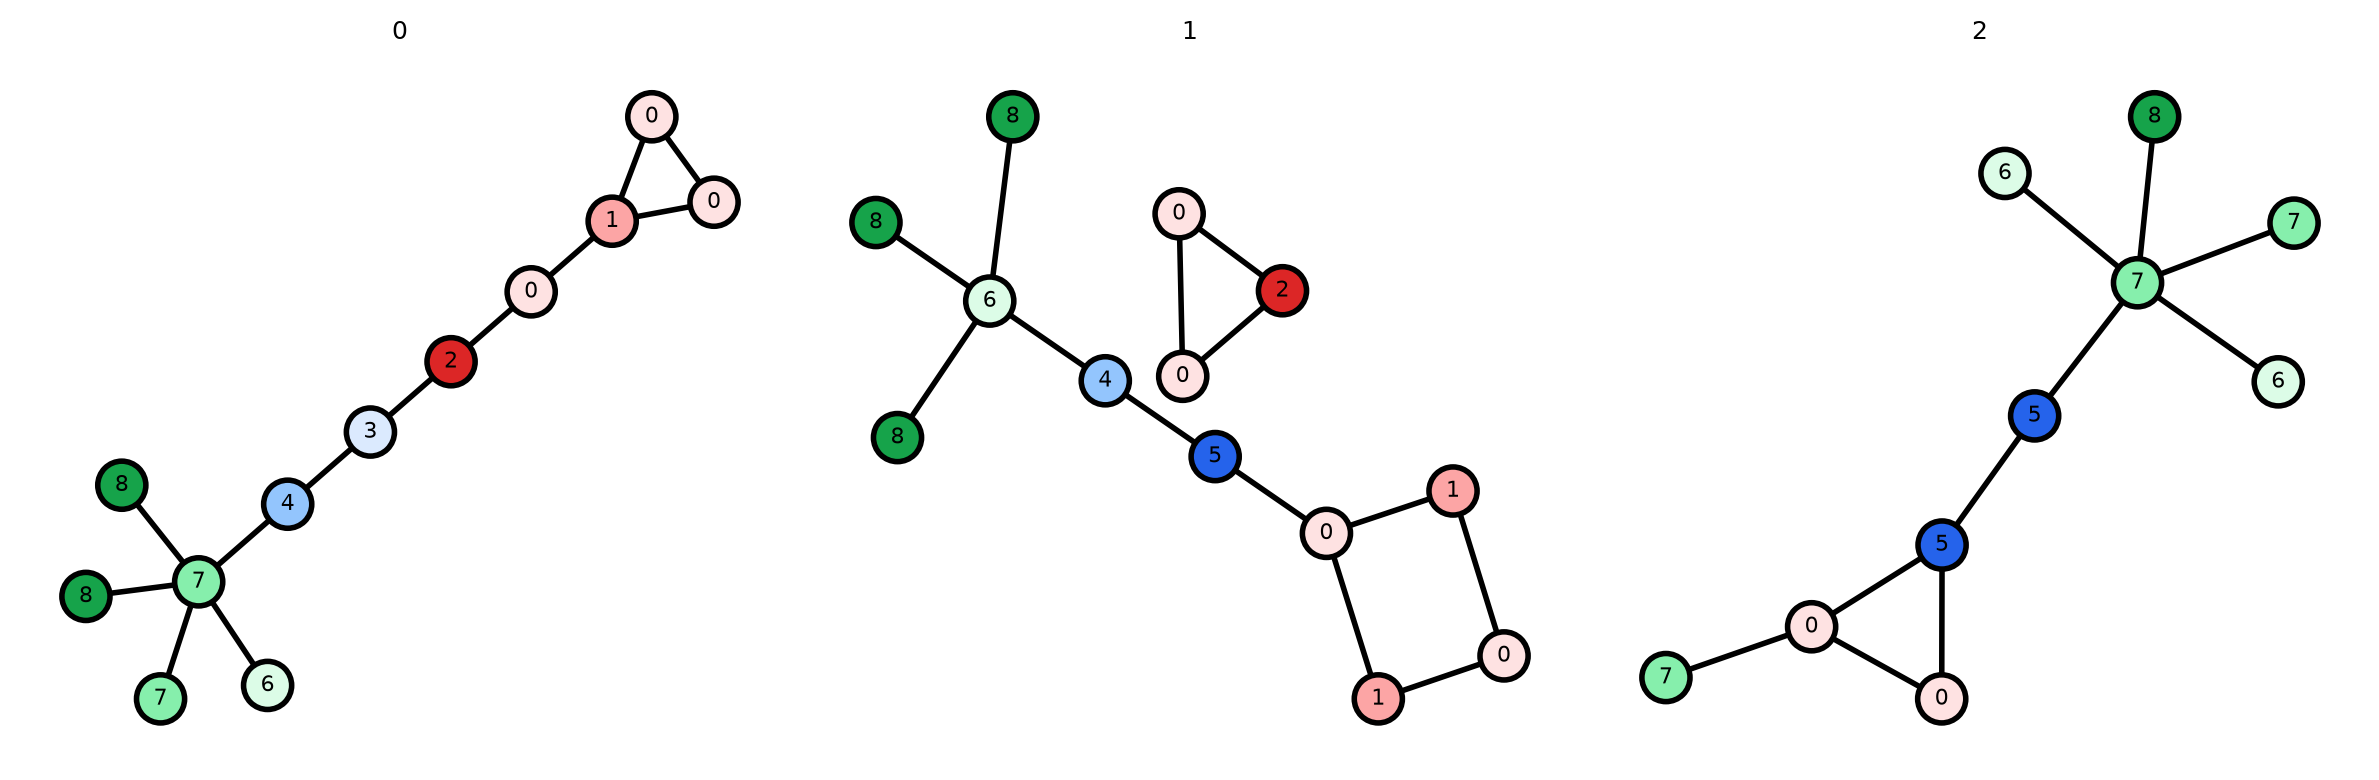

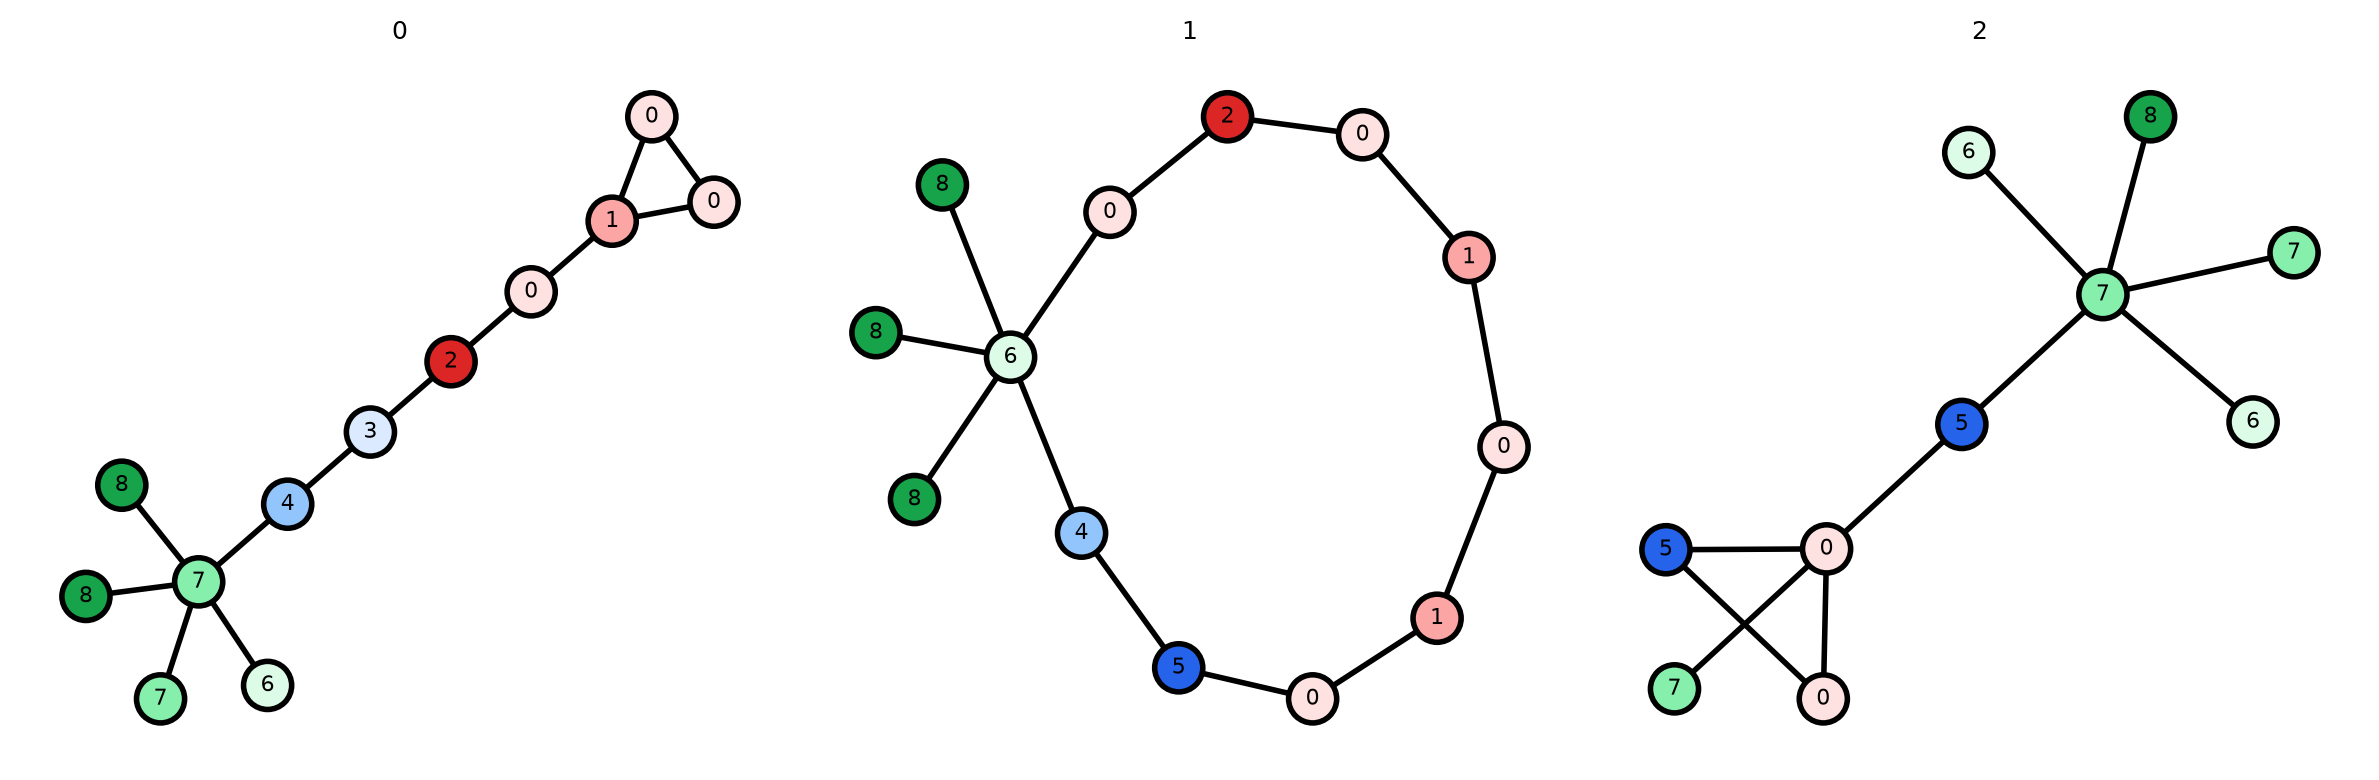

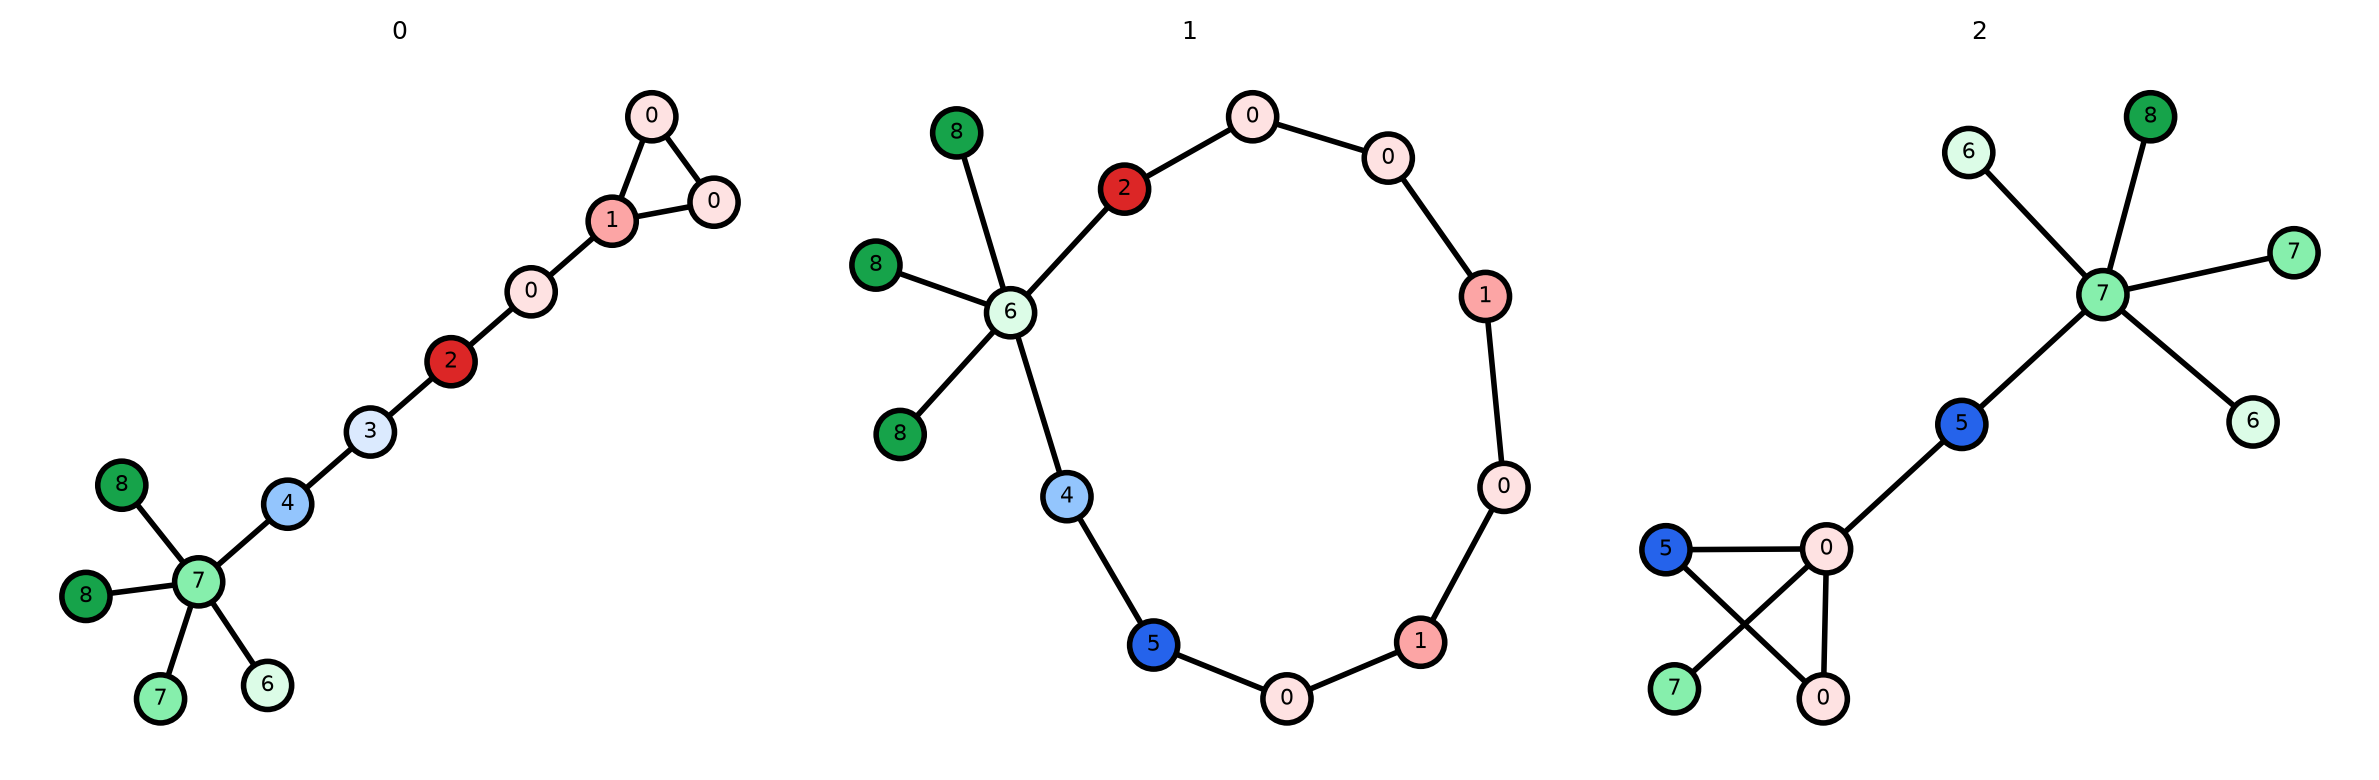

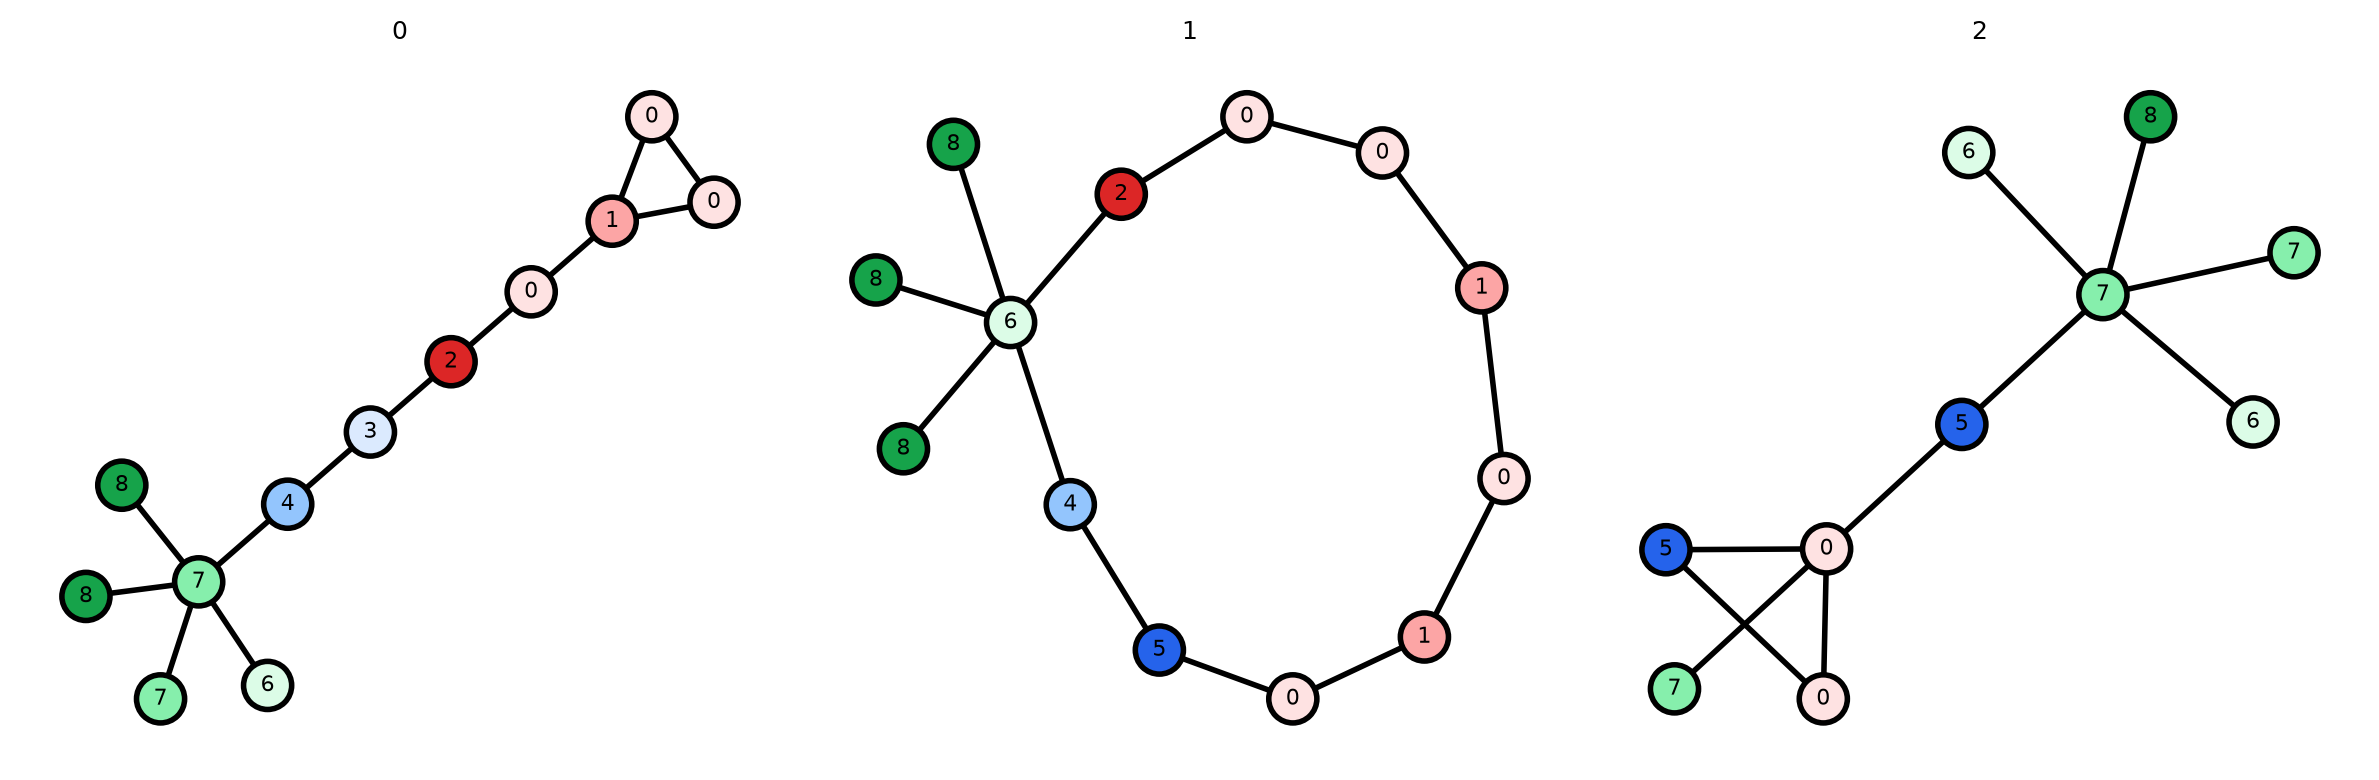

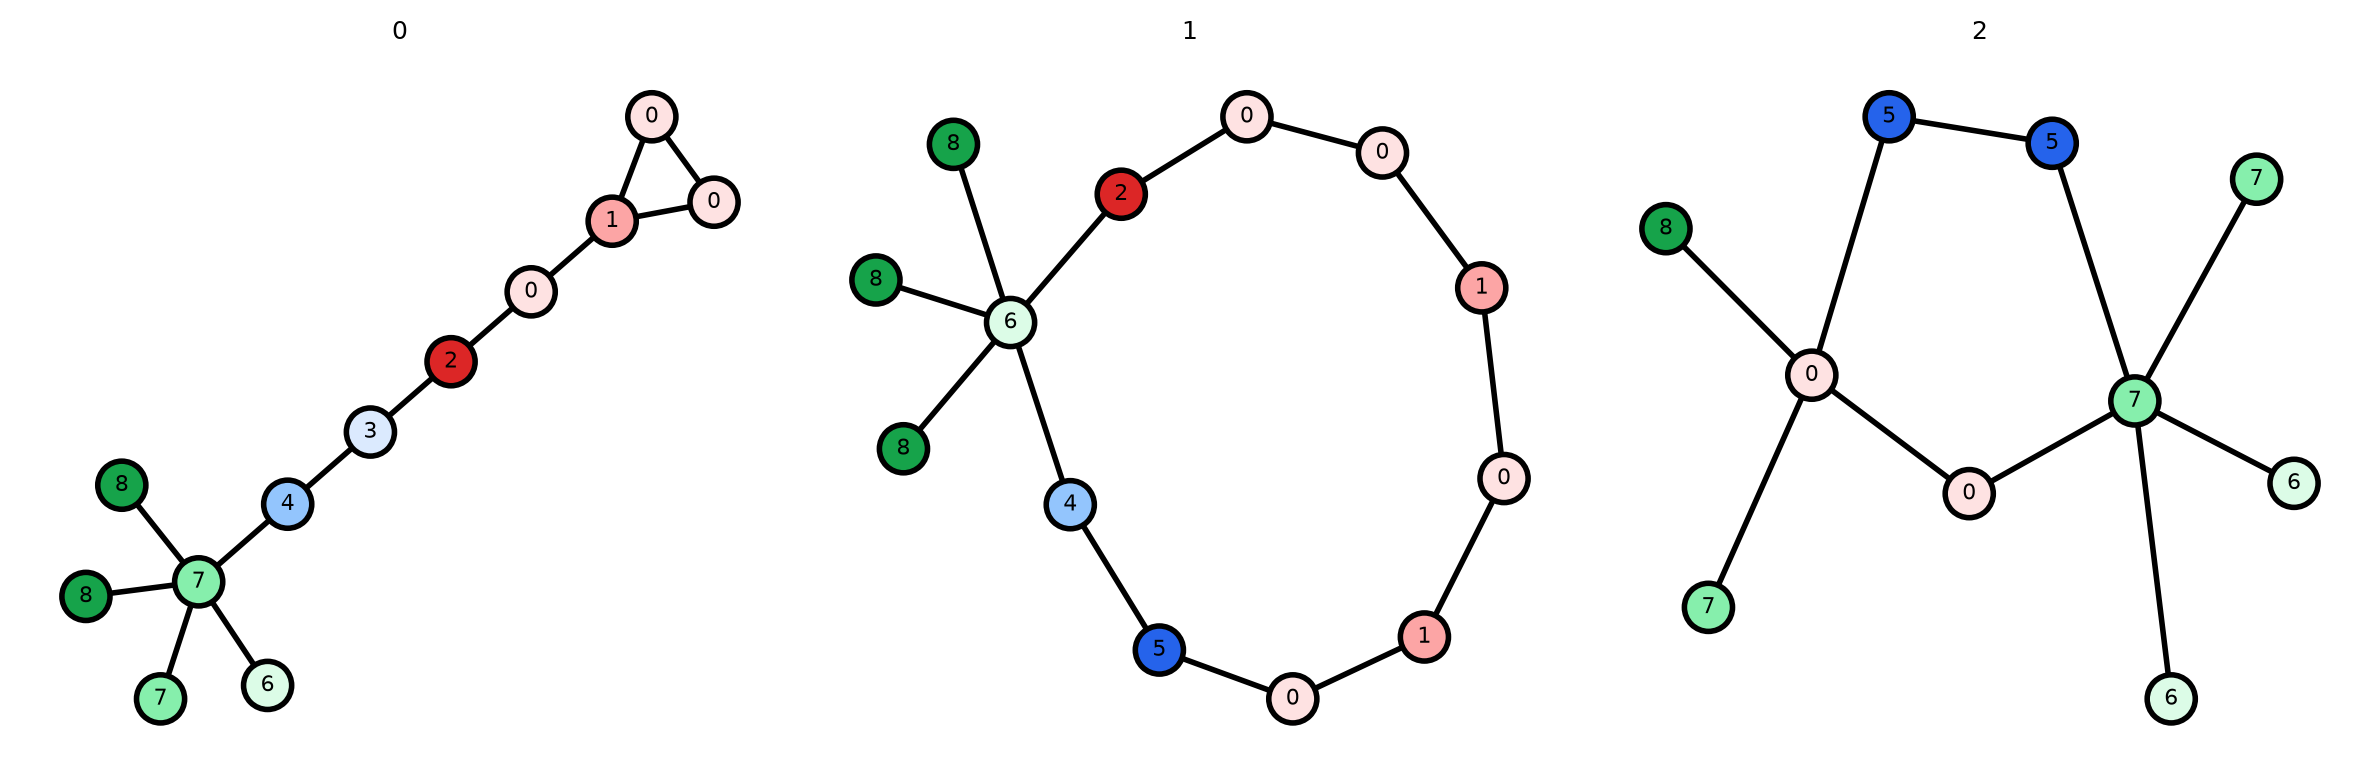

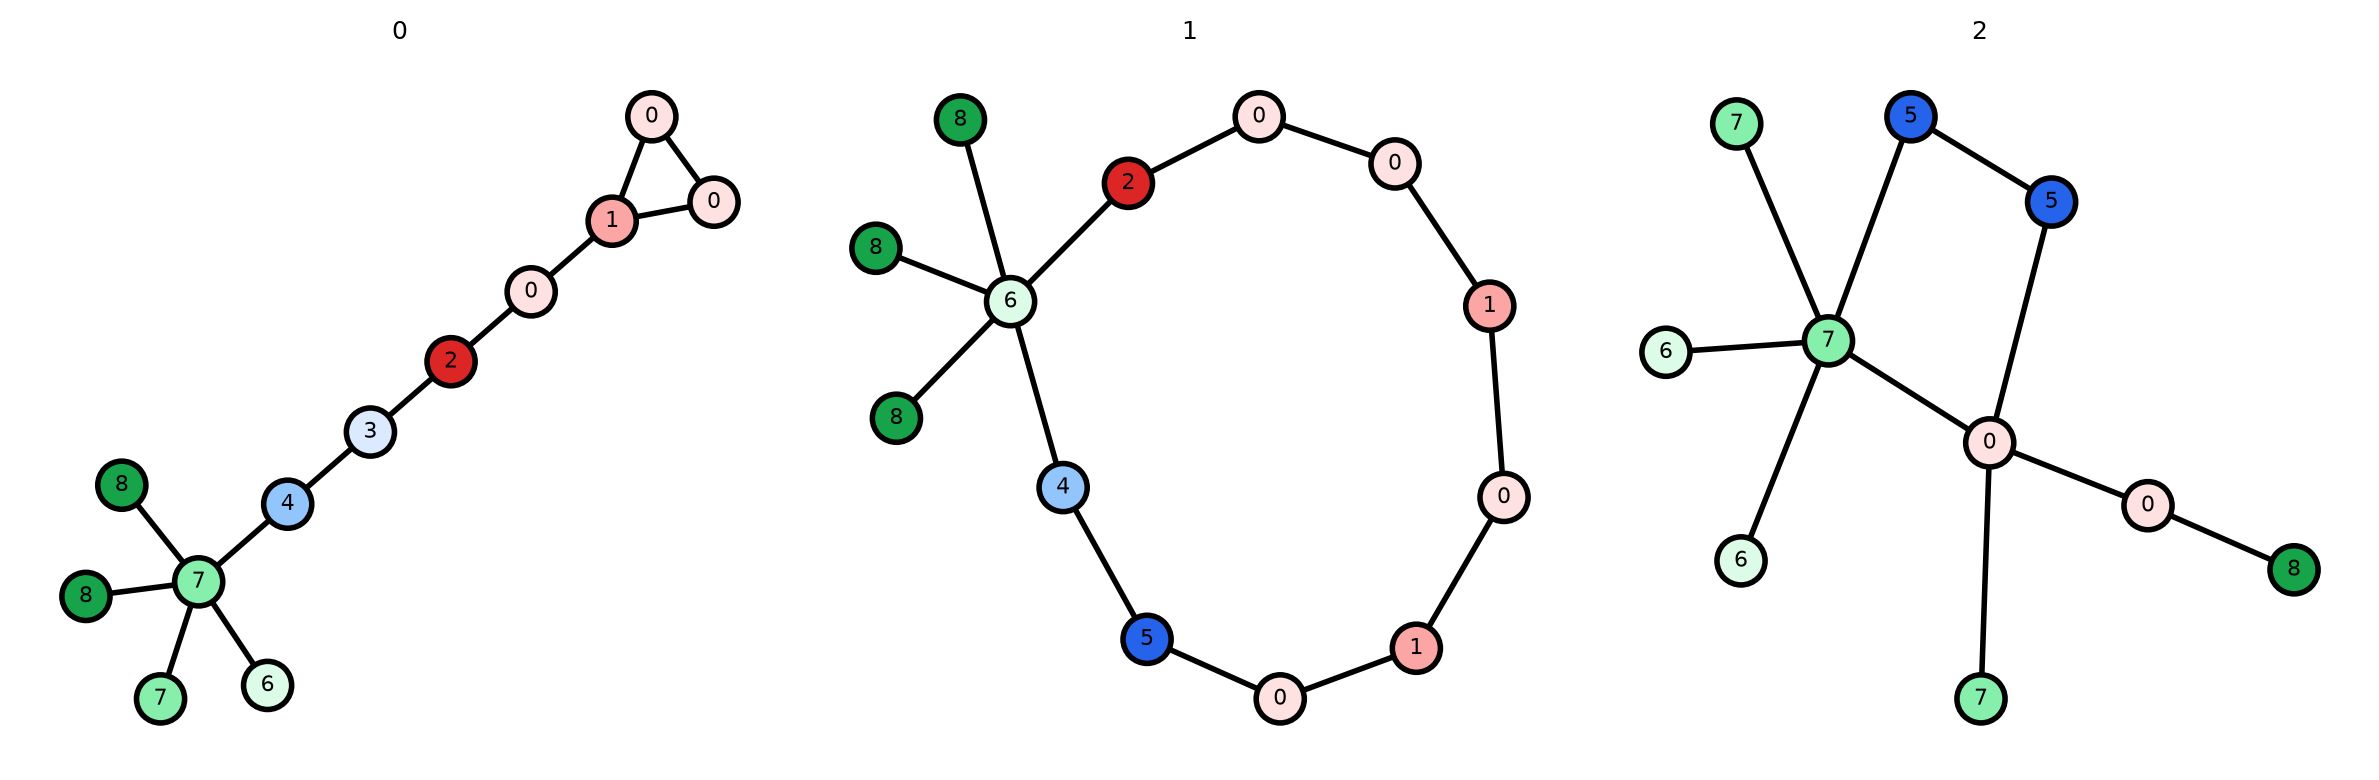

In [10]:
n_samples = 1
sample_variants = graph_generator.sample(n_samples, return_decode_stages=True)

for variant_key in sample_variants:
    variant_samples = sample_variants[variant_key]
    plot_artificial_graphs(
        variant_samples,
        n_cols=n_samples,
        titles=[f'{idx}' for idx in range(len(variant_samples))],
    )

In [ ]:
if graph_generator.feasibility_estimator is None:
    print('Feasibility estimator is unavailable in this environment; skipping filtered sampling.')
else:
    filtered_samples = graph_generator.sample(
        n_samples=n_samples,
        apply_feasibility_filtering=True,
    )
    plot_artificial_graphs(
        filtered_samples,
        n_cols=n_samples,
        titles=[f'filtered {idx}' for idx in range(len(filtered_samples))],
    )
